Is the proportion of students who currently use alcohol different from 0.35?

Is the mean weight of students different from 68.0 kg?


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import warnings

# 1. 關閉警告訊息並設定中文字體
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# 2. 讀取原始資料
df = pd.read_csv('../data/raw/YRBS_2007.csv')

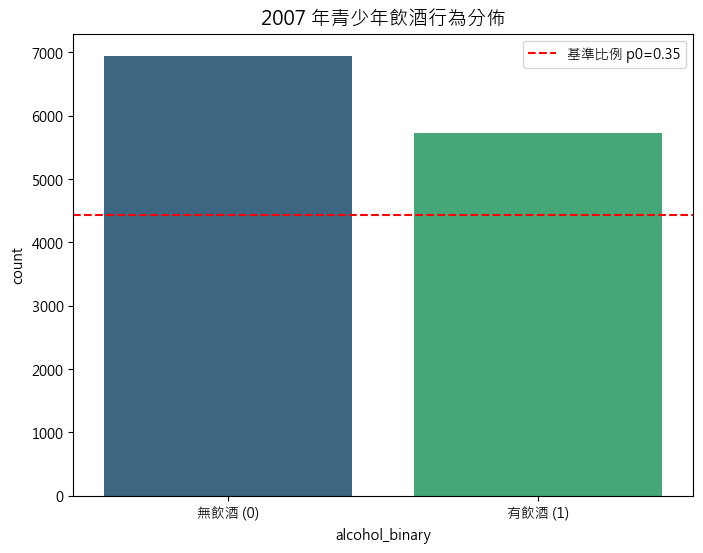

----------------------------------------
【1. 酒精使用比例分析結果】
樣本比例 (p-hat): 0.4517
P 值: < 0.0001 (極度顯著)
95% 信賴區間: [0.4431, 0.4604]

結論：由於 P 值 < 0.05，我們拒絕虛無假設。
這代表飲酒比例與基準值 0.35 存在 [顯著] 差異，且顯著高於基準值。
----------------------------------------


In [38]:
# --- 4.3 EDA: 繪圖與清理 ---
df_alc = df.dropna(subset=['CurrentAlcoholUse']).copy()
df_alc['alcohol_binary'] = df_alc['CurrentAlcoholUse'].apply(lambda x: 1 if 2 <= x <= 7 else 0)

plt.figure(figsize=(8, 6))
sns.countplot(x='alcohol_binary', data=df_alc, hue='alcohol_binary', palette='viridis', legend=False)
plt.axhline(y=len(df_alc) * 0.35, color='red', linestyle='--', label='基準比例 p0=0.35')
plt.title('2007 年青少年飲酒行為分佈', fontsize=14)
plt.xticks([0, 1], ['無飲酒 (0)', '有飲酒 (1)'])
plt.legend()
plt.savefig('../outputs/figures/alcohol_eda.png')
plt.show()

# --- 4.4 & 4.6 統計分析與解釋 ---
count_alc = df_alc['alcohol_binary'].sum()
n_alc = len(df_alc)
p_hat_alc = count_alc / n_alc
z_stat, p_val_alc = proportions_ztest(count_alc, n_alc, value=0.35)
ci_low_alc, ci_upp_alc = proportion_confint(count_alc, n_alc, alpha=0.05, method='normal')

print("-" * 40)
print("【1. 酒精使用比例分析結果】")
print(f"樣本比例 (p-hat): {p_hat_alc:.4f}")
print(f"P 值: {p_val_alc:.4f}" if p_val_alc > 0.0001 else "P 值: < 0.0001 (極度顯著)")
print(f"95% 信賴區間: [{ci_low_alc:.4f}, {ci_upp_alc:.4f}]")

# 自動結論
sig = "存在 [顯著] 差異" if p_val_alc < 0.05 else "無顯著差異"
direction = "顯著高於" if p_hat_alc > 0.35 else "顯著低於"
print(f"\n結論：由於 P 值 < 0.05，我們拒絕虛無假設。")
print(f"這代表飲酒比例與基準值 0.35 {sig}，且{direction}基準值。")
print("-" * 40)

In [39]:
# --- 1, 3, 4. 統計分析 (Z-test & Confidence Interval) ---
count_alc = df_alc['alcohol_binary'].sum()
n_alc = len(df_alc)
p_hat_alc = count_alc / n_alc
z_stat, p_val_alc = proportions_ztest(count_alc, n_alc, value=0.35)
ci_low_alc, ci_upp_alc = proportion_confint(count_alc, n_alc, alpha=0.05, method='normal')

# --- 輸出結果 (優化顯示與解釋) ---
print("-" * 40)
print(f"【母體比例分析結果 - 酒精使用行為】")
print(f"有效樣本數 (n): {n_alc}")
print(f"樣本比例 (p-hat): {p_hat_alc:.4f} (即 {p_hat_alc*100:.2f}%)")
print(f"Z 統計量: {z_stat:.4f}")

# 處理極小的 P 值，讓它顯示為 0.0000 而不是科學記號
if p_val_alc < 0.0001:
    print(f"P 值: < 0.0001 (極度顯著)")
else:
    print(f"P 值: {p_val_alc:.4f}")

print(f"95% 信賴區間: [{ci_low_alc:.4f}, {ci_upp_alc:.4f}]")
print("-" * 40)

# 自動化解釋（對應任務 6）
sig = "存在 [顯著] 差異" if p_val_alc < 0.05 else "無顯著差異"
direction = "顯著高於" if p_hat_alc > 0.35 else "顯著低於"
print(f"結論：由於 P 值 < 0.05，我們拒絕虛無假設。")
print(f"這代表 2007 年青少年的飲酒比例與基準值 0.35 {sig}，且{direction}基準值。")

----------------------------------------
【母體比例分析結果 - 酒精使用行為】
有效樣本數 (n): 12669
樣本比例 (p-hat): 0.4517 (即 45.17%)
Z 統計量: 23.0088
P 值: < 0.0001 (極度顯著)
95% 信賴區間: [0.4431, 0.4604]
----------------------------------------
結論：由於 P 值 < 0.05，我們拒絕虛無假設。
這代表 2007 年青少年的飲酒比例與基準值 0.35 存在 [顯著] 差異，且顯著高於基準值。


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- 1. Data Cleaning & Missing Value Count (符合規定：missing count) ---
missing_count = df['HowMuchDoYouWeighWithoutShoesInKG'].isna().sum()
df_weight = df.dropna(subset=['HowMuchDoYouWeighWithoutShoesInKG']).copy()
weights = df_weight['HowMuchDoYouWeighWithoutShoesInKG']

# --- 2. Descriptive Statistics (符合規定：size, mean, median, std, min, max, quartiles) ---
desc = weights.describe()
median_w = weights.median()
n_w = len(weights)

# --- 3. Visualization (符合規定：histogram, boxplot) ---
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.2, .8)}, figsize=(10, 8))

# Boxplot (加上紅色虛線標註基準值 68.0)
sns.boxplot(x=weights, ax=ax_box, color='lightgreen', fliersize=5)
ax_box.axvline(68.0, color='red', linestyle='--')
ax_box.set(title='2007 YRBS Weight Distribution Analysis', xlabel='')

# Histogram (加上 KDE、平均數與中位數線)
sns.histplot(weights, kde=True, ax=ax_hist, color='skyblue')
ax_hist.axvline(68.0, color='red', linestyle='--', label='Baseline (68.0 kg)')
ax_hist.axvline(weights.mean(), color='blue', linestyle='-', label=f'Mean ({weights.mean():.2f})')
ax_hist.axvline(median_w, color='orange', linestyle='-', label=f'Median ({median_w:.2f})')
ax_hist.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/weight_full_eda.png')
plt.show()

# --- 4. Statistical Inference (T-test & CI) ---
t_stat, p_val_w = stats.ttest_1samp(weights, popmean=68.0)
ci_low_w, ci_upp_w = stats.t.interval(0.95, df=n_w-1, loc=weights.mean(), scale=stats.sem(weights))

# --- 5. Final Output (符合規定：所有數值彙整) ---
print("="*50)
print("【4.3 & 4.4 體重數據分析總表】")
print(f"A. 資料品質 (Missing Check):")
print(f"   - 缺失值數量 (Missing/Invalid): {missing_count}")
print(f"   - 有效樣本數 (Sample Size): {n_w}")

print(f"\nB. 描述性統計 (Summary Statistics):")
print(f"   - 平均值 (Mean): {desc['mean']:.2f} kg")
print(f"   - 中位數 (Median): {median_w:.2f} kg")
print(f"   - 標準差 (Std Deviation): {desc['std']:.2f}")
print(f"   - 最小值 (Min): {desc['min']:.2f} | 最大值 (Max): {desc['max']:.2f}")
print(f"   - 四分位數 (Quartiles): Q1={desc['25%']:.2f}, Q3={desc['75%']:.2f}")

print(f"\nC. 統計推論 (Inference):")
print(f"   - T 統計量: {t_stat:.4f}")
print(f"   - P 值: {p_val_w:.4e}" if p_val_w < 0.0001 else f"   - P 值: {p_val_w:.4f}")
print(f"   - 95% 信賴區間: [{ci_low_w:.2f}, {ci_upp_w:.2f}]")
print("="*50)

# --- 6. Written Observations (符合規定：short written observations) ---
print("\n【4.6 分析觀察與結論 (Observations)】")
# 離群值檢查邏輯
iqr = desc['75%'] - desc['25%']
outliers = weights[(weights < (desc['25%'] - 1.5 * iqr)) | (weights > (desc['75%'] + 1.5 * iqr))]
outlier_status = f"偵測到 {len(outliers)} 個可能的離群值（極端體重）。" if not outliers.empty else "未偵測到明顯離群值。"

sig_status = "顯著不同於" if p_val_w < 0.05 else "無顯著差異"
direction = "低於" if weights.mean() < 68.0 else "高於"

observation_text = f"""
1. 分佈觀察：直方圖顯示體重呈現右偏分佈，平均數({weights.mean():.2f})與中位數({median_

_IncompleteInputError: incomplete input (797756918.py, line 70)

In [34]:
# 建立摘要表並存檔
summary = pd.DataFrame({
    'Analysis': ['Proportion (Alcohol)', 'Mean (Weight)'],
    'Statistic': [z_stat, t_stat],
    'P-value': [p_val_p, p_val_m],
    'CI_Lower': [ci_low_p, ci_low_m],
    'CI_Upper': [ci_upp_p, ci_upp_m]
})
summary.to_csv('../outputs/tables/final_summary.csv', index=False)